<a href="https://colab.research.google.com/github/moralesalessandra29-crypto/LABORATORIO-DE-PDI/blob/main/P6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Práctica 5 - Tipos de Traslaciones de Imágenes



*   2063509 Alessandra Morales Vázquez
*   2055762 Alondra María Cruz Castillo





In [1]:
# Librerías
import cv2
import numpy as np
import matplotlib.pyplot as plt

### **Parte 1**

Ejercicio 1: Suma de Imagenes


---



Se cargaron dos imagenes en escala de grises. Luego se le aplico una suma usando diferentes pesos, lo que nos permite controlar la contribucion de cada imagen en el resultado final.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


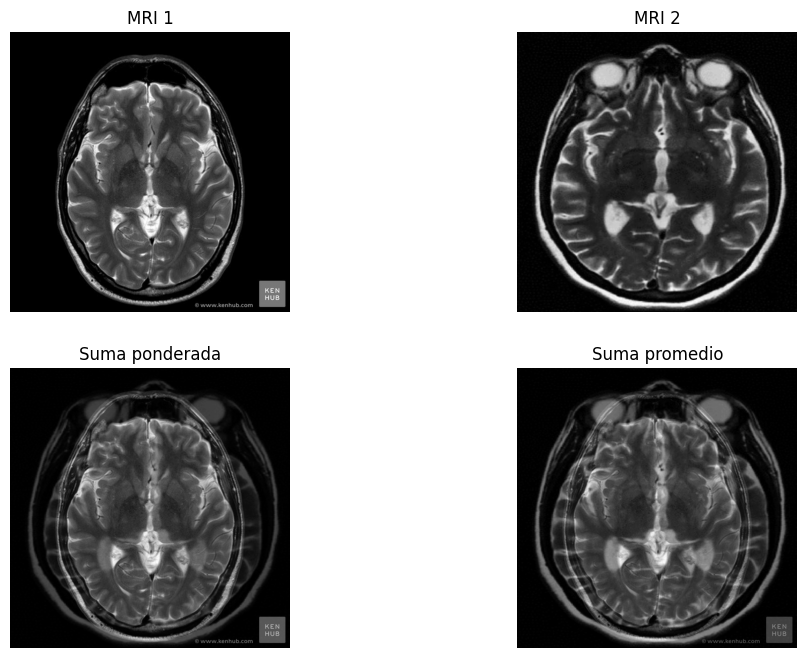

In [4]:
from google.colab import drive
drive.mount('/content/drive')

#IMAGENES
ruta1 = "/content/drive/MyDrive/PDI/MRI1.jpg"
ruta2 = "/content/drive/MyDrive/PDI/MRI2.jpeg"

img1 = cv2.imread(ruta1, cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread(ruta2, cv2.IMREAD_GRAYSCALE)
ancho = img1.shape[1]
alto = img1.shape[0]

# AJUSTAR EL TAMAÑO
if img1.shape != img2.shape:
    img2 = cv2.resize(img2, (ancho, alto))

#IMAGENES ORIGINALES
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title('MRI 1')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(img2, cmap='gray')
plt.title('MRI 2')
plt.axis('off')

#SUMA PONDERADA
alpha = 0.7
beta = 0.3
img_suma_pond = cv2.addWeighted(img1, alpha, img2, beta, 0)
plt.subplot(2, 2, 3)
plt.imshow(img_suma_pond, cmap='gray')
plt.title('Suma ponderada')
plt.axis('off')

#SUMA PROMEDIO
img_prom = (img1.astype(np.float32) + img2.astype(np.float32)) / 2
img_prom = np.uint8(img_prom)
plt.subplot(2, 2, 4)
plt.imshow(img_prom, cmap='gray')
plt.title('Suma promedio')
plt.axis('off')

plt.show()

Ejericio 2: Resta de Imagenes


---
Ahora se realiza la resta de dos imagenes en escala de grises. La resta directa puede generar valores negativos, lo que provoca que se pierda informacion. Se usa una funcion en especial para visualizar la imagen de manera clara.



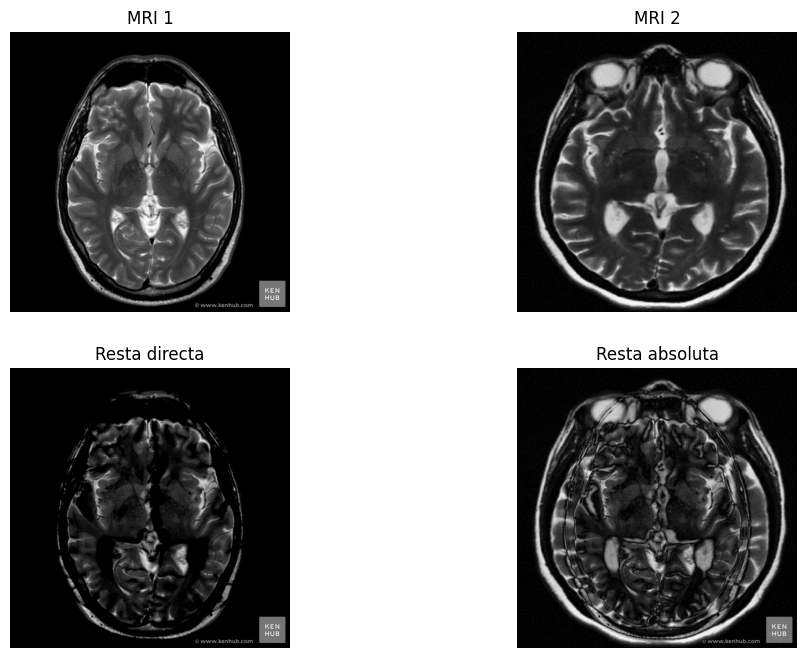

In [5]:
# Ajustar tamaño si es necesario
if img1.shape != img2.shape:
   img2 = cv2.resize(img2, (ancho, alto))

#IMAGENES ORIGINALES
plt.figure(figsize=(12, 8))
plt.subplot(2,2,1)
plt.imshow(img1, cmap='gray')
plt.title('MRI 1')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img2, cmap='gray')
plt.title('MRI 2')
plt.axis('off')

#RESTA DIRECTA
resta = cv2.subtract(img1, img2)
plt.subplot(2,2,3)
plt.imshow(resta, cmap='gray')
plt.title('Resta directa')
plt.axis('off')

#RESTA ABSOLUTA
resta_abs = cv2.absdiff(img1, img2)
plt.subplot(2,2,4)
plt.imshow(resta_abs, cmap='gray')
plt.title('Resta absoluta')
plt.axis('off')

plt.show()

Ejericio 3: Multiplicacion por un Factor


---
Se aplico una multiplicacion para poder modificar su brillo. Se usan factores distintos para poder analizar su efecto sobre la intensidad de los pixeles. Observamos que los valores menores a 1 obscurece la imagen, miestras que los mayores a 1 incremental el brillo.



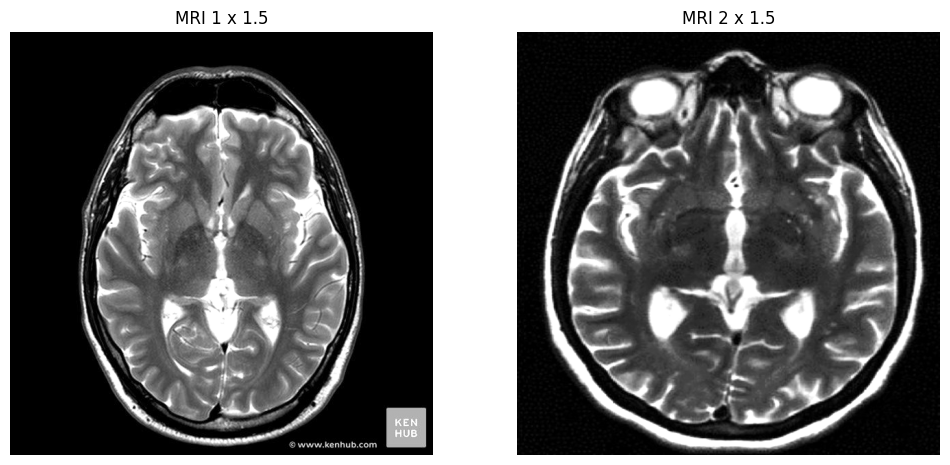

In [8]:
#FACTORES DE MULTIPLICACION
factores = [0.5, 1.0, 1.5]
plt.figure(figsize=(12, 8))

#MRI 1
for i, f in enumerate(factores):
  img_mod = img1.astype(np.float32) * f
  img_mod = np.clip(img_mod, 0, 255)
  img_mod = np.uint8(img_mod)

plt.subplot(1, 2, 1)
plt.imshow(img_mod, cmap='gray')
plt.title(f'MRI 1 x {f}')
plt.axis('off')

#MR 2
for i, f in enumerate(factores):
  img_mod = img2.astype(np.float32) * f
  img_mod = np.clip(img_mod, 0, 255)
  img_mod = np.uint8(img_mod)

plt.subplot(1, 2, 2)
plt.imshow(img_mod, cmap='gray')
plt.title(f'MRI 2 x {f}')
plt.axis('off')

plt.show()

Ejericio 4: Multiplicacion elemento por elemento


---
La multiplicacion de elemento por elemento nos permite resaltar regiones donde ambas presentan valores de instediad altos, lo que es util para identificar coincidencias en algunas estructuras.



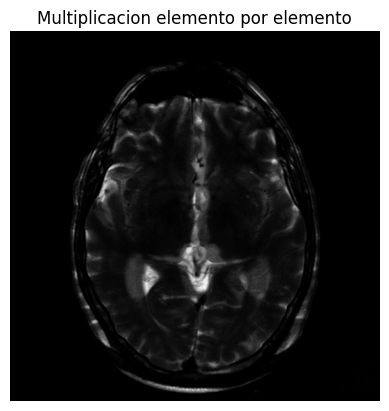

In [9]:
#MULTIPLICACION
img_mult = img1.astype(np.float32) * img2.astype(np.float32)

#NORMALIZAR
img_mult = np.clip(img_mult / 255, 0, 255)
img_mult = np.uint8(img_mult)

#RESULTADO
plt.imshow(img_mult, cmap='gray')
plt.title('Multiplicacion elemento por elemento')
plt.axis('off')
plt.show()

### **Parte 2**

Ejercicio 1: Ecualizacion


---
En este ejercicio se analizo la imagen mediante un histograma, viendo la concentracion de valores en un rango reducido de intensidades. Luego se aplica la ecualizacion que nos va a ayudar a redistribuir los niveles de intensidad.


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


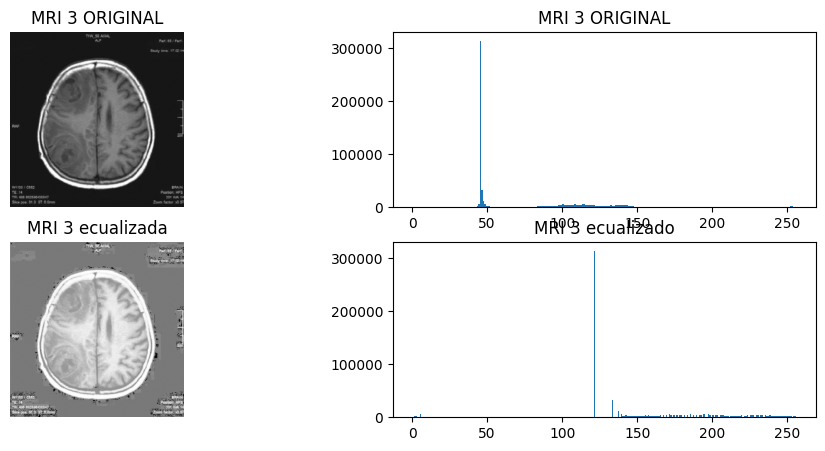

In [13]:
from google.colab import drive
drive.mount('/content/drive')

#IMAGEN
ruta1 = "/content/drive/MyDrive/PDI/MRI3.jpeg"

img1 = cv2.imread(ruta1, cv2.IMREAD_GRAYSCALE)

#HISTOGRAMA ORIGINAL
plt.figure(figsize=(12,5))

plt.subplot(2,2,1)
plt.imshow(img1, cmap='gray')
plt.title('MRI 3 ORIGINAL')
plt.axis('off')

plt.subplot(2,2,2)
plt.hist(img1.ravel(), bins=256, range=[0,256])
plt.title('MRI 3 ORIGINAL')

#ECUALIZACION
img_eq = cv2.equalizeHist(img1)

#IMAGEN ECUALIZADA
plt.subplot(2,2,3)
plt.imshow(img_eq, cmap='gray')
plt.title('MRI 3 ecualizada')
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(img_eq.ravel(), bins=256, range=[0,256])
plt.title('MRI 3 ecualizado')

plt.show()